In [2]:
from datasets import load_dataset
import pandas as pd

# Fix: use full path 'stanfordnlp/imdb'
dataset = load_dataset("stanfordnlp/imdb")

# Convert to dataframe
train_df = pd.DataFrame(dataset['train'])
test_df = pd.DataFrame(dataset['test'])

print(f"Train size: {len(train_df)}")
print(f"Test size:  {len(test_df)}")
print(f"\nClass balance:\n{train_df['label'].value_counts()}")
print(f"\nSample review:\n{train_df['text'][0][:300]}")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md:   0%|          | 0.00/7.81k [00:00<?, ?B/s]

plain_text/train-00000-of-00001.parquet:   0%|          | 0.00/21.0M [00:00<?, ?B/s]

plain_text/test-00000-of-00001.parquet:   0%|          | 0.00/20.5M [00:00<?, ?B/s]

plain_text/unsupervised-00000-of-00001.p(…):   0%|          | 0.00/42.0M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating unsupervised split:   0%|          | 0/50000 [00:00<?, ? examples/s]

Train size: 25000
Test size:  25000

Class balance:
label
0    12500
1    12500
Name: count, dtype: int64

Sample review:
I rented I AM CURIOUS-YELLOW from my video store because of all the controversy that surrounded it when it was first released in 1967. I also heard that at first it was seized by U.S. customs if it ever tried to enter this country, therefore being a fan of films considered "controversial" I really h


In [3]:
import re

def clean_text(text):
    text = text.lower()                            # lowercase
    text = re.sub(r'<.*?>', '', text)              # remove HTML tags like <br />
    text = re.sub(r'[^a-z0-9\s]', '', text)       # remove punctuation
    text = re.sub(r'\s+', ' ', text).strip()       # remove extra whitespace
    return text

# Apply cleaning
train_df['clean_text'] = train_df['text'].apply(clean_text)
test_df['clean_text'] = test_df['text'].apply(clean_text)

# Compare before and after
print("BEFORE:")
print(train_df['text'][0][:300])
print("\nAFTER:")
print(train_df['clean_text'][0][:300])

BEFORE:
I rented I AM CURIOUS-YELLOW from my video store because of all the controversy that surrounded it when it was first released in 1967. I also heard that at first it was seized by U.S. customs if it ever tried to enter this country, therefore being a fan of films considered "controversial" I really h

AFTER:
i rented i am curiousyellow from my video store because of all the controversy that surrounded it when it was first released in 1967 i also heard that at first it was seized by us customs if it ever tried to enter this country therefore being a fan of films considered controversial i really had to s


In [4]:
import nltk
nltk.download('stopwords')
from nltk.corpus import stopwords

stop_words = set(stopwords.words('english'))

def clean_text_v2(text):
    text = text.lower()
    text = re.sub(r'<.*?>', '', text)
    text = re.sub(r'[^a-z0-9\s]', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    # remove stopwords
    words = text.split()
    words = [w for w in words if w not in stop_words]
    return ' '.join(words)

# Apply updated cleaner
train_df['clean_text'] = train_df['clean_text'].apply(lambda x: ' '.join(
    [w for w in x.split() if w not in stop_words]
))
test_df['clean_text'] = test_df['clean_text'].apply(lambda x: ' '.join(
    [w for w in x.split() if w not in stop_words]
))

print("Sample after stopword removal:")
print(train_df['clean_text'][0][:300])

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


Sample after stopword removal:
rented curiousyellow video store controversy surrounded first released 1967 also heard first seized us customs ever tried enter country therefore fan films considered controversial really see myselfthe plot centered around young swedish drama student named lena wants learn everything life particular


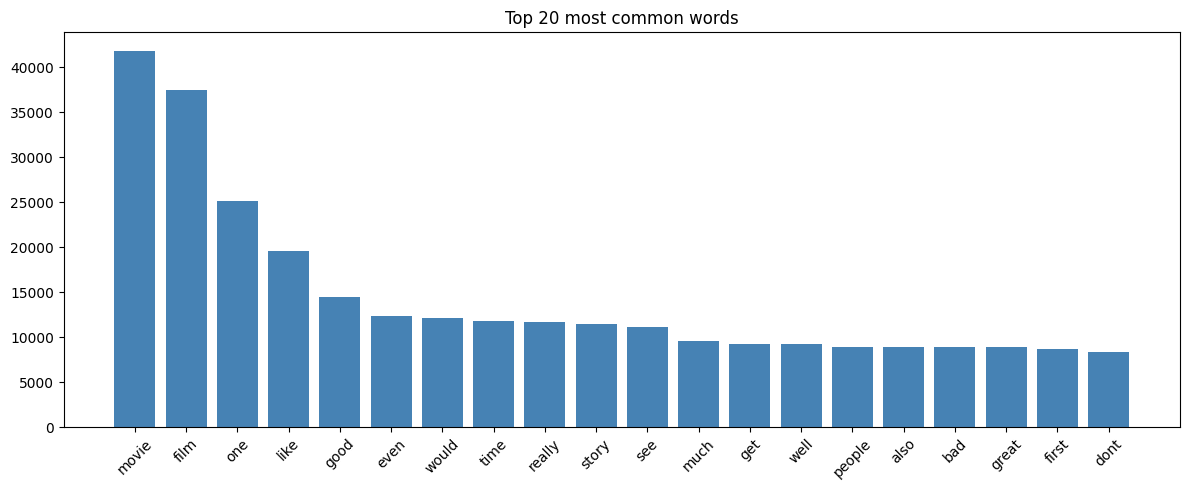

In [5]:
from collections import Counter
import matplotlib.pyplot as plt

# Count all words across training set
all_words = ' '.join(train_df['clean_text']).split()
word_counts = Counter(all_words)
top_words = word_counts.most_common(20)

words, counts = zip(*top_words)
plt.figure(figsize=(12, 5))
plt.bar(words, counts, color='steelblue')
plt.title('Top 20 most common words')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [6]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

# Step 1 — Vectorize text into numbers
vectorizer = TfidfVectorizer(max_features=10000)
X_train = vectorizer.fit_transform(train_df['clean_text'])
X_test = vectorizer.transform(test_df['clean_text'])

y_train = train_df['label']
y_test = test_df['label']

print(f"Training matrix shape: {X_train.shape}")

Training matrix shape: (25000, 10000)


In [7]:
# Step 2 — Train the model
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

# Step 3 — Evaluate
y_pred = model.predict(X_test)

print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print(f"\nDetailed report:")
print(classification_report(y_test, y_pred, target_names=['Negative', 'Positive']))

Accuracy: 0.8818

Detailed report:
              precision    recall  f1-score   support

    Negative       0.88      0.88      0.88     12500
    Positive       0.88      0.88      0.88     12500

    accuracy                           0.88     25000
   macro avg       0.88      0.88      0.88     25000
weighted avg       0.88      0.88      0.88     25000



In [8]:
# Step 4 — Try it yourself
def predict_sentiment(text):
    cleaned = clean_text_v2(text)
    vectorized = vectorizer.transform([cleaned])
    prediction = model.predict(vectorized)[0]
    confidence = model.predict_proba(vectorized)[0].max()
    label = "Positive 😊" if prediction == 1 else "Negative 😞"
    print(f"Review: {text}")
    print(f"Sentiment: {label} (confidence: {confidence:.2%})")

predict_sentiment("This movie was absolutely fantastic, I loved every minute of it")
predict_sentiment("Terrible film, complete waste of time")

Review: This movie was absolutely fantastic, I loved every minute of it
Sentiment: Positive 😊 (confidence: 92.82%)
Review: Terrible film, complete waste of time
Sentiment: Negative 😞 (confidence: 99.74%)


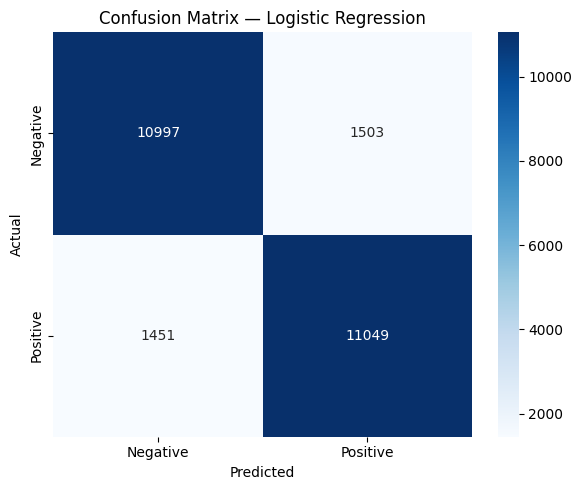

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Negative', 'Positive'],
            yticklabels=['Negative', 'Positive'])
plt.title('Confusion Matrix — Logistic Regression')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

In [10]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC

# Naive Bayes
nb_model = MultinomialNB()
nb_model.fit(X_train, y_train)
nb_pred = nb_model.predict(X_test)

# SVM
svm_model = LinearSVC(max_iter=1000)
svm_model.fit(X_train, y_train)
svm_pred = svm_model.predict(X_test)

print("Naive Bayes accuracy:", accuracy_score(y_test, nb_pred))
print("SVM accuracy:        ", accuracy_score(y_test, svm_pred))

Naive Bayes accuracy: 0.84096
SVM accuracy:         0.86516


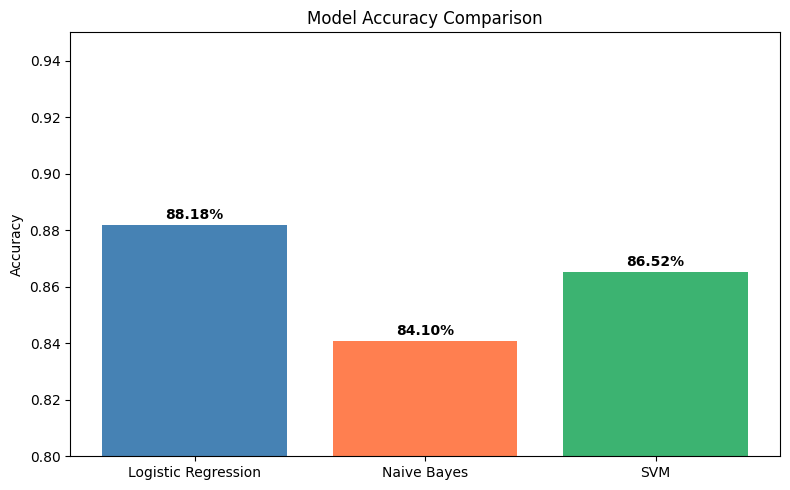

In [11]:
# Model comparison chart
models = ['Logistic Regression', 'Naive Bayes', 'SVM']
scores = [
    accuracy_score(y_test, y_pred),
    accuracy_score(y_test, nb_pred),
    accuracy_score(y_test, svm_pred)
]

plt.figure(figsize=(8, 5))
bars = plt.bar(models, scores, color=['steelblue', 'coral', 'mediumseagreen'])
plt.ylim(0.80, 0.95)
plt.title('Model Accuracy Comparison')
plt.ylabel('Accuracy')
for bar, score in zip(bars, scores):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
             f'{score:.2%}', ha='center', va='bottom', fontweight='bold')
plt.tight_layout()
plt.show()

In [12]:
print("=== Logistic Regression ===")
print(classification_report(y_test, y_pred, target_names=['Negative', 'Positive']))

print("=== Naive Bayes ===")
print(classification_report(y_test, nb_pred, target_names=['Negative', 'Positive']))

print("=== SVM ===")
print(classification_report(y_test, svm_pred, target_names=['Negative', 'Positive']))

=== Logistic Regression ===
              precision    recall  f1-score   support

    Negative       0.88      0.88      0.88     12500
    Positive       0.88      0.88      0.88     12500

    accuracy                           0.88     25000
   macro avg       0.88      0.88      0.88     25000
weighted avg       0.88      0.88      0.88     25000

=== Naive Bayes ===
              precision    recall  f1-score   support

    Negative       0.82      0.87      0.85     12500
    Positive       0.86      0.81      0.84     12500

    accuracy                           0.84     25000
   macro avg       0.84      0.84      0.84     25000
weighted avg       0.84      0.84      0.84     25000

=== SVM ===
              precision    recall  f1-score   support

    Negative       0.86      0.87      0.87     12500
    Positive       0.87      0.86      0.86     12500

    accuracy                           0.87     25000
   macro avg       0.87      0.87      0.87     25000
weighted avg  

In [13]:
# Find misclassified examples
test_df['predicted'] = y_pred
test_df['correct'] = test_df['label'] == test_df['predicted']

# Get wrong predictions
wrong = test_df[test_df['correct'] == False]
print(f"Total misclassified: {len(wrong)} out of {len(test_df)}")
print(f"Error rate: {len(wrong)/len(test_df):.2%}\n")

Total misclassified: 2954 out of 25000
Error rate: 11.82%



In [14]:
# Look at false positives (predicted positive, actually negative)
false_positives = test_df[(test_df['predicted'] == 1) & (test_df['label'] == 0)]
print("=== FALSE POSITIVES (predicted positive, actually negative) ===")
for i, row in false_positives.head(3).iterrows():
    print(f"\n--- Review {i} ---")
    print(row['text'][:300])

=== FALSE POSITIVES (predicted positive, actually negative) ===

--- Review 4 ---
First off let me say, If you haven't enjoyed a Van Damme movie since bloodsport, you probably will not like this movie. Most of these movies may not have the best plots or best actors but I enjoy these kinds of movies for what they are. This movie is much better than any of the movies the other acti

--- Review 11 ---
Blind Date (Columbia Pictures, 1934), was a decent film, but I have a few issues with this film. First of all, I don't fault the actors in this film at all, but more or less, I have a problem with the script. Also, I understand that this film was made in the 1930's and people were looking to escape 

--- Review 18 ---
Ben, (Rupert Grint), is a deeply unhappy adolescent, the son of his unhappily married parents. His father, (Nicholas Farrell), is a vicar and his mother, (Laura Linney), is ... well, let's just say she's a somewhat hypocritical soldier in Jesus' army. It's only when he takes a 

In [15]:
# Look at false negatives (predicted negative, actually positive)
false_negatives = test_df[(test_df['predicted'] == 0) & (test_df['label'] == 1)]
print("=== FALSE NEGATIVES (predicted negative, actually positive) ===")
for i, row in false_negatives.head(3).iterrows():
    print(f"\n--- Review {i} ---")
    print(row['text'][:300])

=== FALSE NEGATIVES (predicted negative, actually positive) ===

--- Review 12508 ---
I finally watched the third film in Mehta's trilogy: "Fire". To begin, I'd say that "Water" was the unquestionable masterpiece, on all levels. Fire comes next with Earth close behind in order of quality. Fire: there is so much going on in this film that I'll need a few more viewings to drink it all 

--- Review 12511 ---
It is more a subtle story of the fact that in Indian household how most decisions are taken by the man, how no attention is paid to the desires of the lady, for example how even when the husband and wife sleep together it would be a test for the husband whether he can control his desires, not to giv

--- Review 12514 ---
This was a bold movie to hit Indian cinemas when it was released. The first movie to perhaps openly depict lesbian tendencies amongst Indian women. The leading actress of Indian cinema Shabana Azmi added substance to the movie with her hot passionate scenes with Nandi

In [16]:
# Summary of error analysis
print("""
=== ERROR ANALYSIS SUMMARY ===

Total errors: 2,954 (11.82% error rate)

Key failure patterns identified:

1. MIXED REVIEWS
   Model struggles when a review contains both positive
   and negative language. Picks up dominant words only.

2. SARCASM & IRONY
   "This movie is much better than..." read as positive
   even in a negative review context.

3. COMPLEX/ANALYTICAL LANGUAGE
   Reviews without obvious sentiment words (great, awful,
   loved, terrible) confuse the TF-IDF approach entirely.

4. CONTEXTUAL SENTIMENT
   "decent film, but I have issues" — the word 'decent'
   pulls toward positive despite overall negative tone.

Conclusion:
   TF-IDF treats text as a bag of words with no context.
   This motivates moving to transformer models (DistilBERT)
   which understand word ORDER and CONTEXT.
""")


=== ERROR ANALYSIS SUMMARY ===

Total errors: 2,954 (11.82% error rate)

Key failure patterns identified:

1. MIXED REVIEWS
   Model struggles when a review contains both positive
   and negative language. Picks up dominant words only.

2. SARCASM & IRONY
   "This movie is much better than..." read as positive
   even in a negative review context.

3. COMPLEX/ANALYTICAL LANGUAGE
   Reviews without obvious sentiment words (great, awful,
   loved, terrible) confuse the TF-IDF approach entirely.

4. CONTEXTUAL SENTIMENT
   "decent film, but I have issues" — the word 'decent'
   pulls toward positive despite overall negative tone.

Conclusion:
   TF-IDF treats text as a bag of words with no context.
   This motivates moving to transformer models (DistilBERT)
   which understand word ORDER and CONTEXT.

